In [1]:
import torch

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from functools import partial
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from src.io import load_data
from src.feature import variance_feature, annotate_labels, our_feature
from src.learning import random_fit_and_eval, RMSE, MAPE
from src.utils import (
    diff_cycles,
    savgol_smooth,
    nankurtosis,
    nanmax,
    nanmin,
    nanmean,
    nanskew,
    nanvar
)

plt.rcParams['font.size'] = 14
%load_ext autoreload
%autoreload 2


In [2]:
# data_folder = Path.cwd().parent / 'data/raw'
data_folder = '/data/Blob_EastUS/xiaofan/battery/all_temp_new/data/raw'
data = load_data(data_folder)

fixed_labels = annotate_labels(data, label_mode='fixed')
relative_labels = annotate_labels(data, label_mode='relative')

Loading cells: 100%|██████████| 151/151 [14:57<00:00,  5.95s/it]


In [3]:
scores = {}
seeds = list(range(16))  # Randomness for dataset split and model initialization
evaluators = [RMSE(log_scale=True), MAPE(log_scale=True)]
num_early_cycles = 50

smoother = partial(savgol_smooth, window=51, order=3)


In [8]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mtick

# # --- Figure & axis -----------------------------------------------------------
# plt.rcParams.update({
#     "font.family": "sans-serif",
#     "font.size"  : 12,        # labels & tick text
# })

# fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# # --- Plot --------------------------------------------------------------------
# ax.plot(
#     cycle_info["V_d"],          # x
#     cycle_info["Q_d"],          # y
#     lw=1,                       # thicker line
#     color="tab:blue",
# )
# ax.scatter(cycle_info["V_d"], cycle_info["Q_d"] , s=5, color='black')

# # --- Axes styling ------------------------------------------------------------
# ax.set_xlabel("Voltage (V)")
# ax.set_ylabel("Capacity (Ah)")   # change units if appropriate

# # ax.invert_xaxis()                # typical for dQ/dV or Q–V curves
# # ax.xaxis.set_major_locator(mtick.MultipleLocator(0.2))
# # ax.yaxis.set_major_locator(mtick.MultipleLocator(0.1))

# ax.grid(True, which="both", ls="--", lw=0.4, alpha=0.5)

# # Remove top/right borders (optional)
# for spine in ["top", "right"]:
#     ax.spines[spine].set_visible(False)
# # plt.gca().set_xticklabels([])
# # plt.gca().set_yticklabels([])
# # fig.tight_layout()
# # plt.savefig('orgin_VQ.svg', format='svg')
# # plt.show()


In [9]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mtick

# # --- Figure & axis -----------------------------------------------------------
# plt.rcParams.update({
#     "font.family": "sans-serif",
#     "font.size"  : 12,        # labels & tick text
# })

# fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# # --- Plot --------------------------------------------------------------------
# ax.plot(
#     # cycle_info["V_d"],          # x
#     cycle_info["QV_d"] *cycle_info['Q_base'],          # y
#     lw=2,                       # thicker line
#     color="tab:blue",
# )
# # ax.scatter(cycle_info["V_d"], cycle_info["Q_d"] , s=5, color='black')


# # --- Axes styling ------------------------------------------------------------
# ax.set_xlabel("Voltage (V)")
# ax.set_ylabel("Capacity (Ah)")   # change units if appropriate

# # ax.invert_xaxis()                # typical for dQ/dV or Q–V curves
# # ax.xaxis.set_major_locator(mtick.MultipleLocator(0.2))
# # ax.yaxis.set_major_locator(mtick.MultipleLocator(0.1))

# ax.grid(True, which="both", ls="--", lw=0.4, alpha=0.5)

# # Remove top/right borders (optional)
# for spine in ["top", "right"]:
#     ax.spines[spine].set_visible(False)


# # plt.gca().set_xticklabels([])
# # plt.gca().set_yticklabels([])
# # fig.tight_layout()
# # plt.savefig('interpolate_VQ.svg', format='svg')


In [4]:

y_relative = np.array([
    label for _, label in relative_labels.items() if label > num_early_cycles
])

X_relative = torch.stack([
    torch.stack([
        torch.stack([
            cycle_data['VQ_c'], cycle_data['VQ_d'],
            cycle_data['dVdQ_c'], cycle_data['dVdQ_d'], 
            cycle_data['interp_I_c'], cycle_data['interp_I_d'],
            cycle_data['interp_V_c'], cycle_data['interp_V_d'],
            cycle_data['QV_c'], cycle_data['QV_d'],
            cycle_data['interp_E_c'], cycle_data['interp_E_d'],
            cycle_data['interp_W_c'], cycle_data['interp_W_d']
        ]) for cycle_data in data[cell][:50]
    ]) for cell, label in relative_labels.items() if label > num_early_cycles
]).permute(0, 2, 1, 3).contiguous()


In [5]:
X_qdlinear = np.stack([
    np.stack([
        cycle_data['Q_d(V_d)'][-1]
        for cycle_data in data[cell][:50]
    ]) 
    for cell, label in relative_labels.items() if label > num_early_cycles
])
X_qdlinear.shape

(95, 50, 100)

In [6]:
def print_score(model_score):
    mean_score = np.mean(model_score, axis=0).squeeze(), np.std(model_score, axis=0).squeeze()
    train_RMSE, test_RMSE, train_RMSE_variance, test_RMSE_variance =  mean_score[0][0][0], mean_score[0][0][1], mean_score[1][0][0], mean_score[1][0][1]
    train_MAPE, test_MAPE, train_MAPE_variance, test_MAPE_variance  =  mean_score[0][1][0], mean_score[0][1][1], mean_score[1][1][0], mean_score[1][1][1]
    print(f'train_RMSE:{train_RMSE:.2f} ± {train_RMSE_variance:.0f}, test_RMSE:{test_RMSE:.2f} ± {test_RMSE_variance:.0f}' )
    print(f'train_MAPE:{train_MAPE:.2f} ± {train_MAPE_variance:.0f}, test_MAPE:{test_MAPE:.2f} ± {test_MAPE_variance:.0f}' )

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_hist(test_label, train_label, fraction=0.7, bins=10, is_save=False, file_path=None):
    sns.set(style="whitegrid")

    # Create the distribution plot
    plt.figure()
    sns.histplot(train_label, kde=True, bins=bins, label='train')
    sns.histplot(test_label, kde=True, bins=bins, label='test')
    

    # sns.histplot(data_800, kde=True, bins=30, label=800)
    # Add labels and title

    plt.xlabel(f'RUL')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of RUL for Training and Testing Sets (Seed 0)')
    plt.legend()
    plt.tight_layout()
    if is_save == True and file_path:
        plt.savefig(file_path)
    # Show the plot
    plt.show()

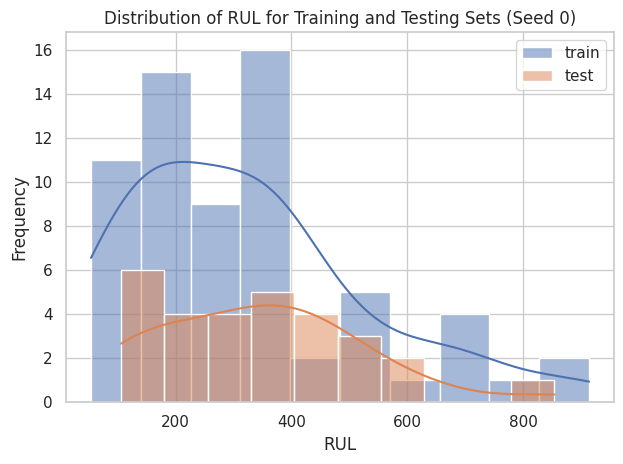

In [ ]:
from src.learning import random_fit_and_eval_new
X, y = X_qdlinear, y_relative
y_train, y_test = random_fit_and_eval_new(
            X.reshape(len(X), -1),
            y_relative,
            models=[DummyRegressor()],
            evaluators=evaluators,
            seed=0,
            return_prediction=True,
            return_train_loss=True
        )
plot_hist(y_test, y_train)

# Dummy

In [8]:
evaluators = [RMSE(log_scale=True), MAPE(log_scale=True)]
predictions = {}
scores = {}
key = 'dummy'
scores[key] = []
predictions[key] = []
X, y = X_qdlinear, y_relative
for seed in seeds:
    score, y_test, y_pred = random_fit_and_eval(
            X.reshape(len(X), -1),
            np.log(y_relative),
            models=[DummyRegressor()],
            evaluators=evaluators,
            seed=seed,
            return_prediction=True,
            return_train_loss=True
        )
    scores[key].append(score)
    predictions[key].append([y_test, y_pred])
print(f'model: {key}')
print_score(scores[key])


model: dummy
train_RMSE:203.13 ± 12, test_RMSE:201.07 ± 29
train_MAPE:67.54 ± 5, test_MAPE:75.34 ± 14


# Variance model

In [9]:

X_diff = X_qdlinear[:, 48, :] - X_qdlinear[:, 8, :]
y = y_relative
Vdlin = np.linspace(4.2, 3.74, 100)
functions = {
    # 'Training set mean':            lambda x: np.mean(train_logrul) * np.ones((len(x), )),
    
    'IQR($\Delta Q_{100-10}$)' :    lambda x: np.percentile(x, 75, axis=1) - np.percentile(x, 25, axis=1),
    'Percentile($\Delta Q_{100-10}$)' :  lambda x: np.percentile(x, 62, axis=1) - np.percentile(x, 31, axis=1),
    '$\Delta Q_{100-10}' + f'({Vdlin[43]:0.3f}$V)':  lambda x: x[:, 43],
    'variance model':   lambda x:np.var(x,axis=1),
}
for k, func in enumerate(functions):
    # print(k, func)
    key = func
    scores[key] = []
    predictions[key] = []
    X = np.log10(np.abs(functions[func](X_diff))).reshape(-1, 1)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    
    for seed in seeds:
        score, y_test, y_pred = random_fit_and_eval(X, np.log(y), [LinearRegression()], evaluators, seed=seed, need_normalize=False, return_prediction=True, return_train_loss=True)
        scores[key].append(score)
        predictions[key].append([y_test, y_pred])

    print(f'model: {key}')
    print_score(scores[key])
    print('\n')


<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'


model: IQR($\Delta Q_{100-10}$)
train_RMSE:201.65 ± 13, test_RMSE:200.96 ± 29
train_MAPE:67.10 ± 5, test_MAPE:76.12 ± 15


model: Percentile($\Delta Q_{100-10}$)
train_RMSE:201.45 ± 13, test_RMSE:200.76 ± 29
train_MAPE:66.98 ± 5, test_MAPE:76.09 ± 15


model: $\Delta Q_{100-10}(4.000$V)
train_RMSE:198.08 ± 12, test_RMSE:194.97 ± 30
train_MAPE:60.44 ± 4, test_MAPE:66.42 ± 12


model: variance model
train_RMSE:201.37 ± 13, test_RMSE:200.56 ± 29
train_MAPE:66.87 ± 5, test_MAPE:75.99 ± 15




/tmp/ipykernel_9584/701117183.py:7: SyntaxWarning: invalid escape sequence '\D'
  'IQR($\Delta Q_{100-10}$)' :    lambda x: np.percentile(x, 75, axis=1) - np.percentile(x, 25, axis=1),
/tmp/ipykernel_9584/701117183.py:8: SyntaxWarning: invalid escape sequence '\D'
  'Percentile($\Delta Q_{100-10}$)' :  lambda x: np.percentile(x, 62, axis=1) - np.percentile(x, 31, axis=1),
/tmp/ipykernel_9584/701117183.py:9: SyntaxWarning: invalid escape sequence '\D'
  '$\Delta Q_{100-10}' + f'({Vdlin[43]:0.3f}$V)':  lambda x: x[:, 43],


# Discharge model

In [10]:
from scipy.stats import skew, kurtosis
def normalize_discharge_features(data):
    functions = {
        'min' :    lambda x: np.min(x, axis=1),
        'var':     lambda x: np.var(x, axis=1),
        'skew':    lambda x: skew(x, axis=1),
        'kurt':    lambda x: kurtosis(x, axis=1),
    }
    
    DeltaQ_50_minus_10 = X_qdlinear[:, 48, :] - X_qdlinear[:, 8, :]
    X = np.ones((DeltaQ_50_minus_10.shape[0],len(functions)+2))
    for k, func in enumerate(functions):
        feat = functions[func](DeltaQ_50_minus_10)
        X[:,k] = feat
    X[:,-2] = data[:,0,1]
    X[:,-1] = np.amax(data[:,0,:],axis=1)- data[:,0,1]
    X[np.isinf(X)] = 0.0
    return X

key = 'discharge'
scores[key] = []
predictions[key] = []
X = normalize_discharge_features(X_qdlinear)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

for seed in seeds:
    score, y_test, y_pred = random_fit_and_eval(X, np.log(y), [LinearRegression()], evaluators, seed=seed, need_normalize=True, return_prediction=True, return_train_loss=True)
    scores[key].append(score)
    predictions[key].append([y_test, y_pred])

print(f'model: {key}')
print_score(scores[key])


model: discharge
train_RMSE:194.52 ± 12, test_RMSE:205.54 ± 28
train_MAPE:59.78 ± 4, test_MAPE:77.01 ± 15


# Full model

In [11]:
def f_cycle_resistance(cycle_info):
    return np.ma.masked_invalid(cycle_info['V_d']/cycle_info['I_d']).mean() 
def get_slope_intercept(y):
    x = np.linspace(1, len(y), len(y))
    z = np.polyfit(x, y, 1)
    return z
def construct_battery_cycle_fullmodel_data(data_tages, data, date_tag2temp,  num_cycles=50):
    # q_d_all = None
    q_d_all = []
    date_sel = []
    charge_times = []
    temperatures = []
    resistances = None
    
    for date_tag in data_tages:
        cycle_infos = data[date_tag]
        # get capacity(discharge)

        q_ds = [cycle_info['Q_d'][-1].tolist() for cycle_info in cycle_infos]   
        q_metrics = np.expand_dims(np.array(q_ds[:num_cycles]), axis=0)
        if isinstance(q_d_all, np.ndarray):
            q_d_all = np.append(q_d_all, q_metrics, axis=0)
        else:
            q_d_all = q_metrics
            
        # get charge time of first 5 cycles
        charge_time= np.mean([len(cycle_info['t_c']) for cycle_info in cycle_infos[:5]])
        charge_times.append(charge_time)
        
        # get temperature
        temperatures.append(int(date_tag2temp[date_tag].split('C')[0]))
        
        # get resistance
        rs = [f_cycle_resistance(cycle_info)  for cycle_info in cycle_infos[:50]]
        
        rs_metrics = np.expand_dims(np.array([np.min(rs),rs[-1] - rs[1]]), axis=0)
        
        if isinstance(resistances, np.ndarray):
            resistances = np.append(resistances, rs_metrics, axis=0)
        else:
            resistances = rs_metrics
            
    return q_d_all, np.array(date_sel), np.array(charge_times), np.array(temperatures), resistances

def build_fullmodel_features(battery_tags,
                            date_tag2cycle_infos,
                            date_tag2temp=None,
                            num_cycles=50):
    functions = {
        'min' :    lambda x: np.min(x, axis=1),
        'var':     lambda x: np.var(x, axis=1),
    }    
    qds,_,charge_times, temperatures, resistances = construct_battery_cycle_fullmodel_data(battery_tags,
                                                                                            date_tag2cycle_infos,date_tag2temp,
                                                                                            num_cycles=num_cycles)
    DeltaQ_50_minus_10_all = X_qdlinear[:, 48, :] - X_qdlinear[:, 8, :]

    X = np.ones((DeltaQ_50_minus_10_all.shape[0],len(functions)+7))

    for k, func in enumerate(functions):
        feat = functions[func](np.nan_to_num(DeltaQ_50_minus_10_all))
        X[:,k] = feat
    # Discharge capacity fade curve features
    # 3.Slope of the linear fit to the capacity fade curve, cycles 2 to 100 ---- linear_fit[0]
    # 4.Intercept of the linear fit to capacity fade curve, cycles 2 to 100 ---- linear_fit[1]
    linear_fit = np.array([get_slope_intercept(qd) for qd in qds])
    # 5.Discharge capacity, cycle 2 ---- capacity2
    capacity2 = qds[:,1]
    # 6.Average charge time, first 5 cycles ------charge_times
    # 7.Integral of temperature over time, cycles 2 to 100  ------ temperatures
    # 8.Minimum internal resistance, cycles 2 to 100-------resistances[0]
    # 9.Internal resistance, difference between cycle 100 and cycle 2 -------resistances[1]
    X[:,2:4] = linear_fit
    X[:,4] = capacity2
    X[:,5] = charge_times
    X[:,6] = temperatures
    X[:,7:] = resistances

    return X



In [50]:
import json
import numpy as np
with open('../data/date_tag2temp.json', 'r') as json_file:
    date_tag2temp = json.load(json_file)
data_tags = [cell for cell, label in relative_labels.items() if label > num_early_cycles]

X = build_fullmodel_features(data_tags,data,date_tag2temp, num_cycles=50)

key = 'full'
scores[key] = []
predictions[key] = []
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

for seed in seeds:
    score, y_test, y_pred = random_fit_and_eval(X, np.log(y), [LinearRegression()], evaluators, seed=seed, need_normalize=True, return_prediction=True, return_train_loss=True)
    scores[key].append(score)
    predictions[key].append([y_test, y_pred])

print(f'model: {key}')
print_score(scores[key])

/tmp/ipykernel_3349229/2608701130.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.ma.masked_invalid(cycle_info['V_d']/cycle_info['I_d']).mean()


model: full
train_RMSE:133.60 ± 10, test_RMSE:156.37 ± 24
train_MAPE:25.46 ± 2, test_MAPE:32.43 ± 5


# Tree based models

In [51]:
from src.learning import tree_models_fit_and_eval
X = X_qdlinear[:, 48, :] - X_qdlinear[:, 8, :]
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

res_score, res_pred = tree_models_fit_and_eval(X, np.log(y), evaluators, seeds, need_normalize=True, return_prediction=True, return_train_loss=True)

for key in res_score.keys():
    scores[key] = res_score[key]
    predictions[key] = res_pred[key]

    print(f'model: {key}')
    print_score(scores[key])


Suggested number of components: 4
Suggested number of components:  2
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}
Suggested number of components: 6
Suggested number of components:  1
{'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 10, 'bootstrap': True}
Suggested number of components: 2
Suggested number of components:  2
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
Suggested number of components: 10
Suggested number of components:  1
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 20, 'bootstrap': True}
Suggested number of components: 3
Suggested number of components:  1
{'n_estimators': 1200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 90, 'bootstrap': True}
Suggested n

In [53]:
for key in res_score.keys():
    print(f'model: {key}')
    print_score(scores[key])
    print('\n')


model: Ridge
train_RMSE:190.73 ± 45, test_RMSE:232.73 ± 132
train_MAPE:62.92 ± 16, test_MAPE:80.39 ± 21


model: Elastic net
train_RMSE:129.90 ± 15, test_RMSE:169.92 ± 26
train_MAPE:30.85 ± 4, test_MAPE:48.82 ± 9


model: PCR
train_RMSE:152.92 ± 15, test_RMSE:164.13 ± 31
train_MAPE:40.22 ± 5, test_MAPE:48.28 ± 6


model: PLSR
train_RMSE:225.77 ± 19, test_RMSE:225.13 ± 29
train_MAPE:79.90 ± 9, test_MAPE:87.70 ± 16


model: RF
train_RMSE:67.95 ± 22, test_RMSE:166.82 ± 29
train_MAPE:11.94 ± 5, test_MAPE:40.33 ± 7




# MLP

In [54]:
from src.learning import MLP_rul_estimator, random_fit_and_eval_nn
key = 'MLP'
scores[key] = []
predictions[key] = []
X = X_qdlinear[:, 48, :] - X_qdlinear[:, 8, :]
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)


for seed in seeds:
    score, pred = random_fit_and_eval_nn(X, np.log(y), [MLP_rul_estimator], evaluators, seed=seed,need_zscore=True, return_prediction=True , return_train_loss=True)
    scores[key].append(score)
    predictions[key].append(pred[0])

print(f'model: {key}')
print_score(scores[key])

model: MLP
train_RMSE:88.39 ± 12, test_RMSE:225.83 ± 29
train_MAPE:16.47 ± 2, test_MAPE:59.85 ± 12


# CNN

In [55]:
from src.learning import CNN_rul_estimator, random_fit_and_eval_nn
key = 'CNN'
scores[key] = []
predictions[key] = []
X = X_qdlinear[:, :, :] - X_qdlinear[:, 8, :][:, np.newaxis, :]

# check for outliers and set values equal to zero
X[np.where(X > 1)] = 0
X[np.where(X < -0.2)] = 0

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)



for seed in seeds:
    score, pred = random_fit_and_eval_nn(X, np.log(y), [CNN_rul_estimator], evaluators, seed=seed,need_zscore=True , return_prediction=True, return_train_loss=True)
    scores[key].append(score)
    predictions[key].append(pred[0])
    
print(f'model: {key}')
print_score(scores[key])

model: CNN
train_RMSE:2.26 ± 1, test_RMSE:153.16 ± 29
train_MAPE:0.42 ± 0, test_MAPE:29.57 ± 5


# Our model

In [16]:
from tqdm import tqdm
from src.feature import our_feature
X_add =np.array([[
        [cycle_data['Q_d'][-1], cycle_data['Q_c'][-1]]
         for cycle_data in data[cell][:50]]
     for cell, label in relative_labels.items() if label > num_early_cycles]
)

def get_slope_intercept(y):
    x = np.linspace(1, len(y), len(y))
    z = np.polyfit(x, y, 1)
    return z

intercept = []
for i in range(X_add.shape[0]):
    intercept.append([get_slope_intercept(X_add[i, :, 0]), get_slope_intercept(X_add[i, :, 1])])
intercept = np.array(intercept)
intercept = intercept.reshape(intercept.shape[0], -1)

import json
with open('./data/date_tag2temp.json', 'r') as json_file:
    date_tag2temp = json.load(json_file)
# data_tags = [cell for cell, label in relative_labels.items() if label > num_early_cycles]

X_temp = np.array([int(date_tag2temp[cell].split('C')[0]) for cell, label in relative_labels.items() if label > num_early_cycles])
X_temp = X_temp.reshape(X_temp.shape[0], -1)

task_type = 'relative'

X, y = eval(f'X_{task_type}'), eval(f'y_{task_type}')
key = 'Ours'
X_ours, fea_names = our_feature(
    X,
    num_cycle_groups=7,
    num_signal_segments=4,
    aggregators=[
        nankurtosis, nanmax, nanmin, nanmean, nanvar, nanskew
    ],
    activators=[
        lambda x: x,  # identity
        torch.abs
    ],
    build_feature_name= True,
    device='cuda:0'
)
X_ours = np.concatenate([X_ours, intercept], axis=1)
fea_names.extend(['Qd_intercept_k','Qd_intercept_b','Qc_intercept_k','Qc_intercept_b'])
print(X_ours.shape, len(fea_names))
X_ours = np.nan_to_num(X_ours, nan=0.0, posinf=0.0, neginf=0.0)


# scores[key] = []
# predictions[key] = []
# feature_importances = []
# for seed in tqdm(seeds, desc=f'Processing {key}'):
#     score, test_y, test_pred = random_fit_and_eval(
#         X_ours, np.log(y), [RandomForestRegressor()], evaluators, seed=seed, return_prediction= True, return_train_loss=True
#     )
#     # score, feature_importance= random_fit_and_eval(
#     #     X_ours, np.log(y), [RandomForestRegressor()], evaluators, seed=seed, feature_name= fea_names, return_train_loss=True
#     # )
#     scores[key].append(score)
#     predictions[key].append(test_pred)

# print(f'model: {key}')
# print_score(scores[key])

(95, 112900) 112900


In [18]:
scores = {}
scores[key] = []
predictions[key] = []
feature_importances = []
for seed in tqdm([0], desc=f'Processing {key}'):
    score, feature_importances, top_idxs = random_fit_and_eval(
        X_ours, np.log(y), [RandomForestRegressor()], evaluators, seed=seed, return_prediction= True, return_train_loss=True, feature_name=fea_names
    )
    # score, feature_importance= random_fit_and_eval(
    #     X_ours, np.log(y), [RandomForestRegressor()], evaluators, seed=seed, feature_name= fea_names, return_train_loss=True
    # )
    scores[key].append(score)
    # predictions[key].append(test_pred)

print(f'model: {key}')
print_score(scores[key])

Processing Ours:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Ours: 100%|██████████| 1/1 [05:08<00:00, 308.45s/it]

model: Ours
train_RMSE:62.21 ± 0, test_RMSE:147.86 ± 0
train_MAPE:8.27 ± 0, test_MAPE:23.77 ± 0


In [21]:
y

array([ 54,  71,  76,  57,  54,  60,  98,  89, 118, 121, 125, 159, 106,
        85, 616, 159, 164, 151, 140, 114, 614, 115, 881, 189, 786, 449,
       175, 245, 259, 486, 914, 675, 368, 364, 524, 692, 509, 324, 523,
       503, 501, 324, 353, 550, 350, 486, 454, 331, 342, 313, 344, 301,
       339, 251, 191, 303, 248, 278, 143, 163, 172, 305, 169, 213, 182,
       854, 203, 201, 233, 164, 439, 238, 246, 157, 674, 203, 367, 371,
       371, 396, 683, 366, 389, 300, 450, 387, 389, 344, 427, 421, 394,
       390, 397, 311, 622])

In [45]:
y[0], y[1]

(np.int64(54), np.int64(71))

In [36]:
import pandas as pd
fea_imp = pd.DataFrame(feature_importances, columns=['Feature', 'Importance'])

In [47]:
bat_idx = 1

fea_imp[f'low rul {y[bat_idx]}'] = X_ours[bat_idx, top_idxs]

In [58]:
fea_imp.head(10)

,Feature,Importance,high 881,high 786,low rul 54,low rul 71,High_1,High_2,Low_1,Low_2
0,identity(nanmean(Cycle(3/7) - Cycle(6/7))[nanm...,0.042078,0.008589,-0.001128,0.192719,0.091173,0.008589,-0.001128,0.192719,0.091173
1,abs(nanmax(Cycle(6/7))[nanvar(VQ_d(1/4))]),0.041188,0.005554,0.005762,0.010815,0.011289,0.005554,0.005762,0.010815,0.011289
2,identity(nanmax(Cycle(6/7))[nanvar(VQ_d(1/4))]),0.020132,0.005554,0.005762,0.010815,0.011289,0.005554,0.005762,0.010815,0.011289
3,abs(nanmax(Cycle(5/7))[nanmean(V_d(4/4))]),0.014114,3.412305,3.400917,3.361094,3.376835,3.412305,3.400917,3.361094,3.376835
4,abs(nanmax(Cycle(7/7))[nanmean(VQ_c(3/4))]),0.014094,4.052670,4.052881,4.197143,4.193614,4.052670,4.052881,4.197143,4.193614
5,identity(nanmin(Cycle(5/7))[nanmax(V_d(2/4))]),0.014040,3.775305,3.771856,3.702740,3.670900,3.775305,3.771856,3.702740,3.670900
6,identity(nanmax(Cycle(4/7) - Cycle(6/7))[nanme...,0.013964,0.001969,0.005720,0.172901,0.056718,0.001969,0.005720,0.172901,0.056718
7,identity(nanmean(Cycle(3/7) - Cycle(6/7))[nanm...,0.013888,19.402855,103.868317,-7.761325,1.564708,19.402855,103.868317,-7.761325,1.564708
8,abs(nanmax(Cycle(2/7) - Cycle(7/7))[nanmean(VQ...,0.013876,0.017776,0.013268,0.132337,0.075312,0.017776,0.013268,0.132337,0.075312
9,abs(nanmax(Cycle(2/7) - Cycle(7/7))[nanmean(VQ...,0.013800,0.016533,0.014795,0.085411,0.054664,0.016533,0.014795,0.085411,0.054664


In [57]:
fea_imp['High_1'] = fea_imp['high 881']
fea_imp['High_2'] = fea_imp['high 786']
fea_imp['Low_1'] = fea_imp['low rul 54']
fea_imp['Low_2'] = fea_imp['low rul 71']

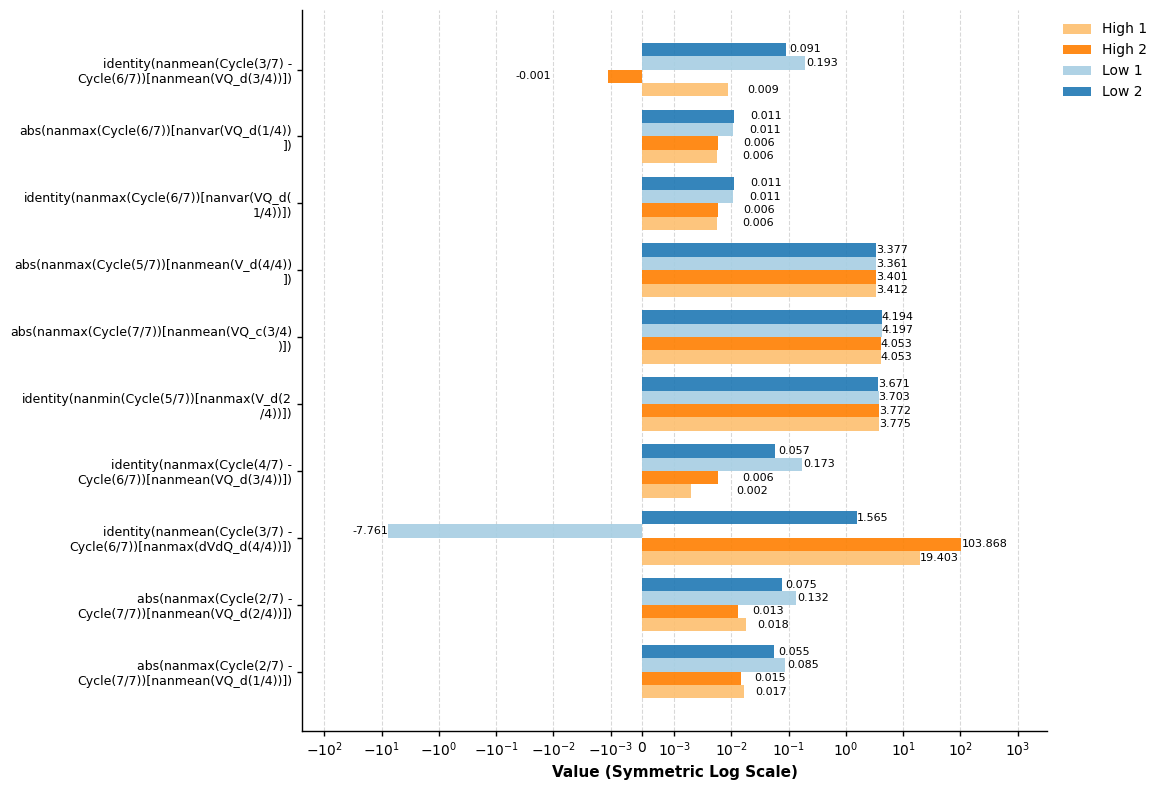

In [63]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

# ---------------------------------------------------------
# 1. 准备数据 (根据您上传的最新图片 image_f1700f.png 手动录入)
# ---------------------------------------------------------
# data = {
#     'Feature': [
#         "identity(nanmean(Cycle(3/7) - Cycle(6/7)))",
#         "abs(nanmax(Cycle(6/7))[nanvar(VQ_d(1/4))])",
#         "identity(nanmax(Cycle(6/7))[nanvar(VQ_d(1/4))])",
#         "abs(nanmax(Cycle(5/7))[nanmean(V_d(4/4))])",
#         "abs(nanmax(Cycle(7/7))[nanmean(VQ_c(3/4))])",
#         "identity(nanmin(Cycle(5/7))[nanmax(V_d(2/4))])",
#         "identity(nanmax(Cycle(4/7) - Cycle(6/7)))",
#         "identity(nanmean(Cycle(3/7) - Cycle(6/7)))_2",
#         "abs(nanmax(Cycle(2/7) - Cycle(7/7)))",
#         "abs(nanmax(Cycle(2/7) - Cycle(7/7)))_2"
#     ],
#     # High 组数据
#     'High_1': [0.192719, 0.010815, 0.010815, 3.361094, 4.197143, 3.702740, 0.172901, -7.761325, 0.132337, 0.085411],
#     'High_2': [0.008589, 0.005554, 0.005554, 3.412305, 4.052670, 3.775305, 0.001969, 19.402855, 0.017776, 0.016533],
#     # Low 组数据
#     'Low_1': [-0.271826, -0.310080, -0.310080, -0.075001, 0.050756, -0.084012, -0.219904, 0.468784, -0.162413, -0.135479],
#     'Low_2': [-0.360777, -0.366593, -0.366593, -0.093949, -0.038077, -0.104257, -0.330906, -0.148030, -0.281160, -0.278942]
# }

# df = pd.DataFrame(data)
df = fea_imp.head(10).copy()
# 特征名换行处理
df['Feature_Wrap'] = df['Feature'].apply(lambda x: '\n'.join(textwrap.wrap(x, width=40)))
# df['Feature_Wrap'] = df['Feature']

# ---------------------------------------------------------
# 2. 设置 Nature 风格绘图参数
# ---------------------------------------------------------
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0

# 定义色系: 橙色系 (High) 和 蓝色系 (Low)
# 使用十六进制颜色码，深浅搭配
orange_palette = ['#FDBF6F', '#FF7F00']  # 浅橙, 深橙
blue_palette = ['#A6CEE3', '#1F78B4']    # 浅蓝, 深蓝

bar_height = 0.2  # 每个柱子的高度，需要更窄以放下4个

# ---------------------------------------------------------
# 3. 绘图逻辑
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8)) # 增加宽度以容纳文本标签

y_pos = np.arange(len(df))

# 计算每个柱子的位置偏移
# 顺序: High_1, High_2, Low_1, Low_2
offsets = [bar_height*1.5, bar_height*0.5, -bar_height*0.5, -bar_height*1.5]
columns = ['High_1', 'High_2', 'Low_1', 'Low_2']
colors = orange_palette + blue_palette
labels = ['High 1', 'High 2', 'Low 1', 'Low 2']

rects = []
for i, col in enumerate(columns):
    # 绘制柱子
    r = ax.barh(y_pos + offsets[i], df[col], bar_height,
                label=labels[i], color=colors[i], edgecolor='none', alpha=0.9)
    rects.append(r)

    # 在柱子头上添加数值文本
    for rect, value in zip(r, df[col]):
        width = rect.get_width()
        # 根据值的正负决定文本在左侧还是右侧
        xloc = width + (0.01 if value >= 0 else -0.01) 
        # 文本对齐方式
        ha = 'left' if value >= 0 else 'right'
        
        ax.text(xloc, rect.get_y() + rect.get_height()/2.0,
                f'{value:.3f}',  # 格式化为3位小数
                ha=ha, va='center', fontsize=8, color='black')

# ---------------------------------------------------------
# 4. 美化图表
# ---------------------------------------------------------

# 设置 Y 轴
ax.set_yticks(y_pos)
ax.set_yticklabels(df['Feature_Wrap'], fontsize=9)
ax.invert_yaxis()
ax.margins(x=0.15)
# 设置 X 轴 (使用 symlog 以处理数据范围和负数)
ax.set_xlabel('Value (Symmetric Log Scale)', fontsize=11, weight='bold')
# linthresh 需要根据数据中最小的非零绝对值来调整，这里设为 0.005
ax.set_xscale('symlog', linthresh=1e-3, linscale=0.5)

# 去掉边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加图例
ax.legend(frameon=False, loc='upper right', fontsize=10, bbox_to_anchor=(1.15, 1))

# 添加网格线
ax.xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.3)
ax.set_axisbelow(True)

# 紧凑布局
plt.tight_layout()

plt.savefig('./output/high_low_feature.png', dpi=300)

In [ ]:
plt

In [30]:
# import pickle
# with open('../output/rul_baseline_scores_with_trainloss.pkl', 'wb') as f:
#     pickle.dump(scores, f)

In [76]:
import pickle
with open('../output/rul_baseline_scores.pkl', 'wb') as f:
    pickle.dump(scores, f)

In [77]:
import pickle
with open('../output/rul_baseline_predictions.pkl', 'wb') as f:
    pickle.dump(predictions, f)

In [ ]:
# # save feature importance(figure 3c data)
# import pandas as pd
# fea_imp_data = []
# for seed in range(16):
#     for item in range(20):
#         # print(feature_importances[seed][0][item])
#         fea_imp_data.append([seed, feature_importances[seed][0][item][0], feature_importances[seed][0][item][1]])

# fea_imp = pd.DataFrame(fea_imp_data, columns= ['seed', 'feature_name', 'score'])
# fea_imp.to_csv('../output/feature_importance_rul_v2_cycle7.csv')


In [61]:
# save rul result to csv
table = []
columns = ['model','Train RMSE mean', 'Train RMSE var', 'Test RMSE mean', 'Test RMSE var','Train MAPE mean', 'Train MAPE var', 'Test MAPE mean', 'Test MAPE var']
for key in scores.keys():
    mean = np.mean(scores[key], axis=0).squeeze()
    std = np.std(scores[key], axis=0).squeeze()

    table.append([key, mean[0][0], std[0][0], mean[0][1], std[0][1], mean[1][0], std[1][0], mean[1][1], std[1][1]])
import pandas as pd
result_df = pd.DataFrame(data=table, columns=columns)
result_df["Train RMSE"] = result_df.apply(lambda x: f'{x["Train RMSE mean"]:.2f} ± {x["Train RMSE var"]:.0f}', axis=1)
result_df["Test RMSE"] = result_df.apply(lambda x: f'{x["Test RMSE mean"]:.2f} ± {x["Test RMSE var"]:.0f}', axis=1)

result_df["Train MAPE"] = result_df.apply(lambda x: f'{x["Train MAPE mean"]:.2f} ± {x["Train MAPE var"]:.0f}', axis=1)
result_df["Test MAPE"] = result_df.apply(lambda x: f'{x["Test MAPE mean"]:.2f} ± {x["Test MAPE var"]:.0f}', axis=1)
result_df.to_csv('../output/rul_result.csv')


In [62]:
result_df

,model,Train RMSE mean,Train RMSE var,Test RMSE mean,Test RMSE var,Train MAPE mean,Train MAPE var,Test MAPE mean,Test MAPE var,Train RMSE,Test RMSE,Train MAPE,Test MAPE
0,dummy,203.134811,12.154343,201.065250,28.887598,67.538099,4.782769,75.335884,14.087980,203.13 ± 12,201.07 ± 29,67.54 ± 5,75.34 ± 14
1,IQR($\Delta Q_{100-10}$),201.651440,12.676576,200.963270,29.391738,67.099646,4.963870,76.121547,14.617702,201.65 ± 13,200.96 ± 29,67.10 ± 5,76.12 ± 15
2,Percentile($\Delta Q_{100-10}$),201.446507,12.686250,200.758371,29.396101,66.975500,5.007179,76.089733,14.667789,201.45 ± 13,200.76 ± 29,66.98 ± 5,76.09 ± 15
3,$\Delta Q_{100-10}(4.000$V),198.083403,12.104242,194.973832,29.750986,60.435122,4.202508,66.418591,11.583464,198.08 ± 12,194.97 ± 30,60.44 ± 4,66.42 ± 12
4,log 10 (var(ΔQ100−10 (V))),201.369140,12.561115,200.564685,29.277580,66.867512,4.923524,75.991538,14.517059,201.37 ± 13,200.56 ± 29,66.87 ± 5,75.99 ± 15
5,variance model,201.369140,12.561115,200.564685,29.277580,66.867512,4.923524,75.991538,14.517059,201.37 ± 13,200.56 ± 29,66.87 ± 5,75.99 ± 15
6,discharge,194.518024,12.134357,205.540412,28.051679,59.776774,4.365243,77.012919,15.013498,194.52 ± 12,205.54 ± 28,59.78 ± 4,77.01 ± 15
7,full,133.603623,9.657945,156.367022,23.513141,25.462375,1.519148,32.428540,5.325984,133.60 ± 10,156.37 ± 24,25.46 ± 2,32.43 ± 5
8,Ridge,190.730431,45.470946,232.726216,132.050929,62.923172,15.774443,80.386768,21.345038,190.73 ± 45,232.73 ± 132,62.92 ± 16,80.39 ± 21
9,Elastic net,129.902910,15.030695,169.916577,26.258038,30.845703,3.907817,48.815793,8.734797,129.90 ± 15,169.92 ± 26,30.85 ± 4,48.82 ± 9
